In [34]:
import pybirewirex as pbr
import pandas as pd
import os
import numpy as np
import argparse
import igraph as ig
from igraph import Graph
from itertools import combinations
from multiprocessing import Pool
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt
import ast
import sys
from tqdm import tqdm

# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

#n_permutations = 5000
n_permutations = 5000
ncpus = os.environ['NCPUS']

# Get actual interactions
ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc.csv')
ccc['complex_a'] = ccc['complex_a'].apply(lambda x: ast.literal_eval(x))
ccc['complex_b'] = ccc['complex_b'].apply(lambda x: ast.literal_eval(x))
ccc['all_genes'] = ccc['all_genes'].apply(lambda x: ast.literal_eval(x)).apply(set)
ccc_gene_sets = set(tuple(sorted(gene_set)) for gene_set in ccc['all_genes'])

def find_motifs(
    network,
    adj,
    #ccc_gene_sets, NOT ACTUALLY USED, permutations are encoded in network['ccc']
    ):
    
    # Generate pairs of significant interactions
    int_pairs = pd.Series(combinations(pd.Index(network.query('ccc')[['complex1', 'complex2']]), 2))
    int_pairs.index = int_pairs.apply(lambda x: '+'.join(x[0]) + '&' + '+'.join(x[1]))
    int_pairs_genes = int_pairs.apply(lambda x: sorted(set(x[0]).union(x[1])))
    
    # Divide into triplets (2 interactions share a complex) and quadruplets (no shared complexes)
    triplets = int_pairs_genes[int_pairs_genes.apply(len) == 3]
    quadruplets = int_pairs_genes[int_pairs_genes.apply(len) == 4]

    # Count triplets
    g1 = ig.Graph([(0, 1), (1, 2)], directed=False) # 0-1-2 e.g 2 ligands share same receptor, but ligs aren't coexpressed
    g2 = ig.Graph([(0, 1), (1, 2), (2, 0)], directed=False) # clique

    possible_motifs = {
        '3_path': g1,
        '3_clique': g2
    }

    motifs = {}

    for k in possible_motifs.keys():
        motifs[k] = []

    for label, genes in triplets.items():
        subgraph = Graph.Adjacency(adj.loc[genes, genes], mode=ig.ADJ_UNDIRECTED)
        for key, motif in possible_motifs.items():
            if subgraph.isomorphic(motif):
                motifs[key].append(label)
                continue
    
    # Count quadruplets
    g1 = ig.Graph([(0, 3), (1, 2)], directed=False) # no crosstalk
    g2 = ig.Graph([(0, 3), (1, 2), (0, 1)], directed=False) # path or 3-chain
    g3 = ig.Graph([(0, 3), (1, 2), (0, 2), (0, 1)], directed=False) # triangle with exta link
    g4 = ig.Graph([(1, 3), (0, 3), (1, 2), (0, 2)], directed=False) # cycle (4 nodes loop)
    g5 = ig.Graph([(1, 3), (0, 3), (1, 2), (0, 2), (0, 1)], directed=False) # one missing (al pairs are connected except one)
    g6 = ig.Graph([(2, 3), (1, 3), (0, 3), (1, 2), (0, 2), (0, 1)], directed=False) # clique

    possible_motifs = {
        '4_no_crosstalk': g1,
        '4_path': g2,
        '4_triangle_extra': g3,
        '4_cycle' :g4,
        '4_one_missing' :g5,
        '4_clique' :g6,
    }

    for k in possible_motifs.keys():
        motifs[k] = []
        
    for label, genes in quadruplets.items():
        subgraph = Graph.Adjacency(adj.loc[genes, genes], mode=ig.ADJ_UNDIRECTED)
        for key, motif in possible_motifs.items():
            if subgraph.isomorphic(motif):
                motifs[key].append(label)
                continue
    
    # Make series with number of motifs
    counts = pd.Series({k: len(v) for k, v in motifs.items()})
    
    return motifs, counts

# Old Rewiring
def old_permutation_test(args):
    i, ccc, network = args

    np.random.seed(i)          
    
    network = network.copy()
    ccc = ccc.copy()

    fake_all_genes = ccc.complex_a + ccc.complex_b.sample(frac=1, replace=False).reset_index(drop=True)
    fake_ccc_gene_sets = set(tuple(sorted(gene_set)) for gene_set in fake_all_genes)
    network['ccc'] = False                 
    network['ccc'] = network['all_genes'].apply(lambda genes: tuple(genes) in fake_ccc_gene_sets)

    _, fake_counts = find_motifs(network, adj)
    return fake_counts

In [15]:
def rewire_bipartite_edges(df, colA, colB, seed):
    # Define partitions
    A_nodes = sorted(set(df[colA]))
    B_nodes = sorted(set(df[colB]))

    A_index = {a: i for i, a in enumerate(A_nodes)}
    B_index = {b: i for i, b in enumerate(B_nodes)}

    # Build incidence matrix
    M = np.zeros((len(A_nodes), len(B_nodes)), dtype=np.int8)

    ia = np.array([A_index[x] for x in df[colA]])
    ib = np.array([B_index[x] for x in df[colB]])

    M[ia, ib] = 1

    # Rewire
    M_rewired = pbr.rewire_bipartite(M, seed=seed)

    # Back to edge list
    ia, ib = np.where(M_rewired == 1)

    edges = set((A_nodes[i], B_nodes[j]) for i, j in zip(ia, ib))

    return edges, A_nodes, B_nodes

In [16]:
def permutation_test(args):
    i, ccc, network, rewire_network, rewire_ccc, ccc_mode = args

    np.random.seed(i)
    network = network.copy()

    # =========================
    # PREPARE NETWORK
    # =========================
    nodes = pd.Index(sorted(set(network['complex1']) | set(network['complex2'])))
    node_index = {n: idx for idx, n in enumerate(nodes)}

    n = len(nodes)
    net_adj = np.zeros((n, n), dtype=np.int8)

    ia = np.array([node_index[x] for x in network['complex1']])
    ib = np.array([node_index[x] for x in network['complex2']])

    net_adj[ia, ib] = 1
    net_adj[ib, ia] = 1

    # =========================
    # NETWORK REWIRING
    # =========================
    if rewire_network:
        rewired_net_adj = pbr.rewire_undirected(net_adj, seed=i)
    else:
        rewired_net_adj = net_adj

    adj_rewired = pd.DataFrame(rewired_net_adj, index=nodes, columns=nodes)

    # =========================
    # CCC HANDLING
    # =========================
    if not rewire_ccc:
        # KEEP ORIGINAL CCC
        pass

    else:
        # --- SHUFFLE (gene-level, original behavior) ---
        if ccc_mode == "shuffle":

            ccc_tmp = ccc.copy()

            fake_all_genes = (
                ccc_tmp['complex_a'] +
                ccc_tmp['complex_b'].sample(frac=1, random_state=i).reset_index(drop=True)
            )

            fake_ccc_gene_sets = set(
                tuple(sorted(gene_set))
                for gene_set in fake_all_genes
            )

            network['ccc'] = network['all_genes'].apply(
                lambda genes: tuple(sorted(genes)) in fake_ccc_gene_sets
            )

        # --- REWIRE (edge-level bipartite) ---
        elif ccc_mode == "rewire":

            ccc_tmp = ccc.copy()
            ccc_tmp['A'] = ccc_tmp['complex_a'].str.join('_')
            ccc_tmp['B'] = ccc_tmp['complex_b'].str.join('_')

            ccc_edges, _, _ = rewire_bipartite_edges(
                ccc_tmp, 'A', 'B', seed=i
            )

            edge_set = ccc_edges
            pairs = list(zip(network['complex1'], network['complex2']))

            network['ccc'] = pd.Series(pairs).isin(edge_set).values

        else:
            raise ValueError(f"Invalid ccc_mode: {ccc_mode}")

    # =========================
    # MOTIF DETECTION
    # =========================
    _, fake_counts = find_motifs(network, adj_rewired)

    return fake_counts

In [35]:
null_models = {
    # (rewire_network, rewire_ccc, ccc_mode)
    "ccc_rewire":      (False, True,  "shuffle"),
    "network_rewire":   (True,  False, None),
    "both_rewire":     (True,  True,  "shuffle"),
}

# =========================
# RUN PIPELINE
# =========================
for condition in ['tumor']:  # add 'normal', 'both' if needed
    print('Condition:', condition)
    print('Reading network')

    network = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/network_filtered.csv')
    network['all_genes'] = network['all_genes'].apply(lambda x: ast.literal_eval(x))

    if condition == 'tumor':
        network = network.query('auroc > 0.5')
    elif condition == 'normal':
        network = network.query('auroc < 0.5')

    # =========================
    # BUILD ADJACENCY
    # =========================
    edges = list(zip(network['complex1'], network['complex2']))
    G = Graph.TupleList(edges, directed=False)

    nodes = G.vs['name']
    adj = pd.DataFrame(G.get_adjacency(), index=nodes, columns=nodes)

    # =========================
    # REAL MOTIFS (once)
    # =========================
    print('Finding motifs (real)')
    motifs, counts = find_motifs(network, adj)

    outdir_base = f'/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/{condition}'
    os.makedirs(outdir_base, exist_ok=True)

    counts = counts.reset_index()
    counts.columns = ['motif', 'number']

    print('Actual motifs detected:', counts)

    # =========================
    # RUN NULL MODELS
    # =========================
    for model_name, (rewire_network, rewire_ccc, ccc_mode) in null_models.items():

        print(f'\nRunning model: {model_name}')
        print(f'  rewire_network={rewire_network}, rewire_ccc={rewire_ccc}, ccc_mode={ccc_mode}')

        outdir = os.path.join(outdir_base, model_name)
        os.makedirs(outdir, exist_ok=True)

        # =========================
        # PERMUTATIONS
        # =========================
        with Pool(int(ncpus)) as p:
            fake_counts = pd.DataFrame(
                list(
                    tqdm(
                        p.imap(
                            permutation_test,
                            [
                                (
                                    i,
                                    ccc,
                                    network,
                                    rewire_network,
                                    rewire_ccc,
                                    ccc_mode
                                )
                                for i in range(n_permutations)
                            ]
                        ),
                        total=n_permutations
                    )
                )
            )

        # =========================
        # SAVE RESULTS
        # =========================
        print('Saving results')

        fake_counts.to_csv(
            os.path.join(outdir, 'motifs_permutations.csv'),
            index=False
        )

    # =========================
    # SAVE REAL COUNTS
    # =========================
    counts.to_csv(
        os.path.join(outdir_base, 'counts_real.csv'),
        index=False
    )

print('Done: motifs.py')

Condition: tumor
Reading network
Finding motifs (real)
Actual motifs detected:               motif  number
0            3_path     450
1          3_clique     487
2    4_no_crosstalk    8048
3            4_path    9280
4  4_triangle_extra   10453
5           4_cycle    1658
6     4_one_missing    5992
7          4_clique    3818

Running model: ccc_rewire
  rewire_network=False, rewire_ccc=True, ccc_mode=shuffle


100%|██████████| 5000/5000 [21:27<00:00,  3.88it/s]


Saving results

Running model: network_rewire
  rewire_network=True, rewire_ccc=False, ccc_mode=None


100%|██████████| 5000/5000 [1:18:11<00:00,  1.07it/s]


Saving results

Running model: both_rewire
  rewire_network=True, rewire_ccc=True, ccc_mode=shuffle


100%|██████████| 5000/5000 [21:37<00:00,  3.85it/s]


Saving results
Done: motifs.py


In [37]:
import os
import pandas as pd

condition = "tumor"
base_dir = f"/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/{condition}"

models = ["ccc_shuffle", "network_rewire", "both_shuffle"]

all_fake_counts = {}

for model in models:
    path = os.path.join(base_dir, model, "motifs_permutations.csv")

    print(f"Loading {model} from {path}")

    df = pd.read_csv(path)

    all_fake_counts[model] = df

counts = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/counts_real.csv')

print("Done loading all permutation results.")

Loading ccc_shuffle from /home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/ccc_shuffle/motifs_permutations.csv
Loading network_rewire from /home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/network_rewire/motifs_permutations.csv
Loading both_shuffle from /home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/both_shuffle/motifs_permutations.csv
Done loading all permutation results.


Processing ccc_shuffle


/var/tmp/pbs.434162.pbs01/ipykernel_8785/1381864322.py:41: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df3 = (df3.T / df3.sum(1)).T
/var/tmp/pbs.434162.pbs01/ipykernel_8785/1381864322.py:42: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df4 = (df4.T / df4.sum(1)).T


Processing both_shuffle


/var/tmp/pbs.434162.pbs01/ipykernel_8785/1381864322.py:41: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df3 = (df3.T / df3.sum(1)).T
/var/tmp/pbs.434162.pbs01/ipykernel_8785/1381864322.py:42: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df4 = (df4.T / df4.sum(1)).T


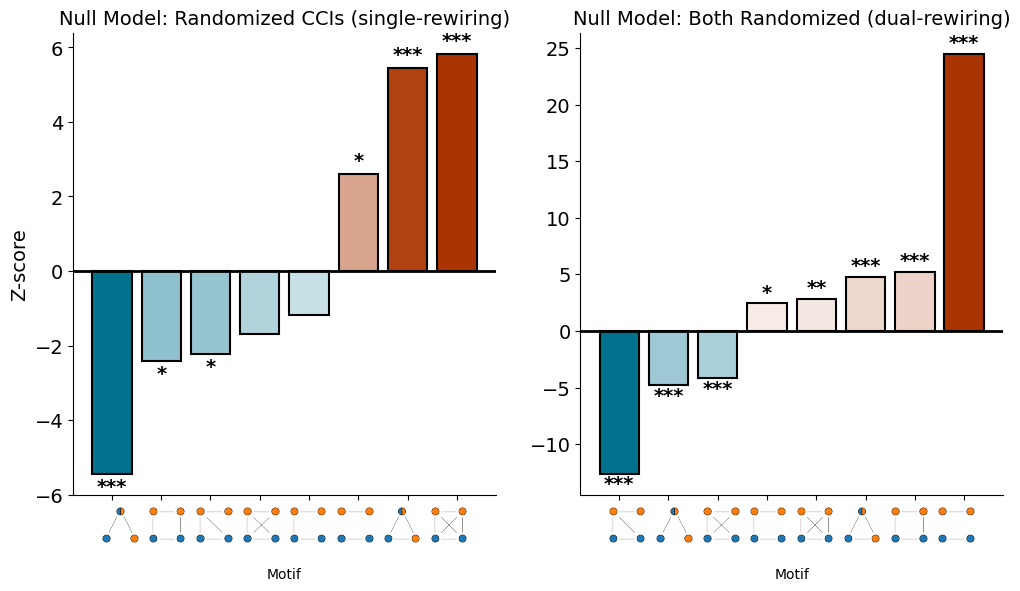

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import os

#models = ["ccc_shuffle", "network_rewire", "both_shuffle"]
models = ["ccc_shuffle", "both_shuffle"]

fig, axes = plt.subplots(1, len(models), figsize=(12, 6))#, sharey=True)

img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons'
fs = 14

for ax, model in zip(axes, models):

    print(f"Processing {model}")

    df = all_fake_counts[model]  # permutation results for this model

    # -------------------------
    # Real motif counts
    # -------------------------
    motifs = counts.set_index('motif')['number']

    # -------------------------
    # Split motif classes
    # -------------------------
    df3 = df[[c for c in df.columns if c.startswith('3')]]
    df4 = df[[c for c in df.columns if c.startswith('4')]]

    motifs3 = motifs.loc[[i for i in motifs.index if i.startswith('3')]]
    motifs4 = motifs.loc[[i for i in motifs.index if i.startswith('4')]]

    # normalize real counts
    motifs3 = motifs3 / motifs3.sum()
    motifs4 = motifs4 / motifs4.sum()

    # normalize null distributions
    df3 = (df3.T / df3.sum(1)).T
    df4 = (df4.T / df4.sum(1)).T

    df_model = df3.join(df4)
    motifs_model = pd.concat([motifs3, motifs4])

    # -------------------------
    # Z-score computation
    # -------------------------
    means = df_model.mean()
    stds = df_model.std().replace(0, np.nan)

    motifs_z = ((motifs_model - means) / stds).dropna().sort_values()
    motifs_z.name = 'z'

    motifs_names = motifs_z.index
    z_scores = motifs_z.values

    # -------------------------
    # Color mapping
    # -------------------------
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'custom_gradient', [ncolor, 'white', tcolor]
    )
    norm = mcolors.TwoSlopeNorm(
        vmin=np.nanmin(z_scores),
        vcenter=0,
        vmax=np.nanmax(z_scores)
    )
    colors = cmap(norm(z_scores))

    # -------------------------
    # Plot bars
    # -------------------------
    bars = ax.bar(
        motifs_names,
        z_scores,
        color=colors,
        edgecolor='black',
        linewidth=1.5
    )

    # zero line
    ax.axhline(0, color='black', linewidth=2)

    # shared y label
    axes[0].set_ylabel("Z-score", fontsize=fs)

    # -------------------------
    # Significance (FDR)
    # -------------------------
    null_center = np.mean(df_model, axis=0)

    p_values = (
        (np.abs(motifs_model - null_center) <= np.abs(df_model - null_center)).sum(axis=0)
        / df_model.shape[0]
    )

    p_values = pd.Series(false_discovery_control(p_values), index=p_values.index)
    p_values = p_values.reindex(motifs_names)

    sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

    for bar, z, p in zip(bars, z_scores, p_values):
        if pd.isna(p):
            continue

        sig_symbol = next((s for thr, s in sig_levels.items() if p <= thr), None)

        if sig_symbol:
            y = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                y + (0.1 if y > 0 else -0.1),
                sig_symbol,
                ha='center',
                va='bottom' if y > 0 else 'top',
                fontsize=fs,
                fontweight='bold'
            )

    # -------------------------
    # Titles / styling
    # -------------------------
    axes[0].set_title('Null Model: Randomized CCIs (single-rewiring)', fontsize=14)
    #axes[1].set_title('Null Model: Randomized Co-Expression', fontsize=16)
    axes[1].set_title('Null Model: Both Randomized (dual-rewiring)', fontsize=14)    
    
    ax.set_xticklabels([])
    ax.set_xlabel("Motif", labelpad=45)
    
    ax.spines[['right', 'top']].set_visible(False)
    ax.tick_params(axis='both', labelsize=fs)

    # -------------------------
    # Add motif icons
    # -------------------------
    img_width = 0.06
    fig.canvas.draw()

    xl, yl, xh, yh = np.array(ax.get_position()).ravel()
    h = yh - yl

    for i, label in enumerate(motifs_names):
        img_path = os.path.join(img_dir, f"{label}.png")

        if not os.path.exists(img_path):
            continue

        img = mpimg.imread(img_path)

        x_pos = xl + ( (i+1) / (len(motifs_names) + 1) * (xh - xl))

        ax_img = fig.add_axes([
            x_pos - img_width/2,
            yl - 0.08,
            img_width,
            img_width
        ])
        ax_img.axis('off')
        ax_img.imshow(img)

plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/tumor_motifs_enrichment_new_rewiring_dual.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/tumor_motifs_enrichment_new_rewiring_dual.png', bbox_inches='tight')
        
#plt.tight_layout()
plt.show()

In [68]:
motifs_z

motif
4_triangle_extra   -12.620512
3_path              -4.789027
4_one_missing       -4.149423
4_path               2.458345
4_clique             2.861999
3_clique             4.789027
4_cycle              5.231715
4_no_crosstalk      24.486221
Name: z, dtype: float64

In [39]:
counts.sum()

motif     3_path3_clique4_no_crosstalk4_path4_triangle_e...
number                                                40186
dtype: object

In [40]:
for k, df in all_fake_counts.items():
    print(k, df.sum(1).mean())

ccc_shuffle 10594.0272
network_rewire 16990.598
both_shuffle 3912.717


/var/tmp/pbs.434162.pbs01/ipykernel_8785/2879534342.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print(k, df.sum(1).mean())
/var/tmp/pbs.434162.pbs01/ipykernel_8785/2879534342.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print(k, df.sum(1).mean())
/var/tmp/pbs.434162.pbs01/ipykernel_8785/2879534342.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  print(k, df.sum(1).mean())


In [ ]:
all_fake_counts['ccc_shuffle'].sum(1).mean()

In [11]:
outdir

'/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring/tumor/both_rewire'

In [4]:
# Original
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_permutations.csv')
motifs = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/counts.csv', index_col='motif')
motifs = motifs['number'] 

df3 = df[[col for col in df.columns if col.startswith('3')]]
df4 = df[[col for col in df.columns if col.startswith('4')]]
motifs3 = motifs.loc[[idx for idx in motifs.index if idx.startswith('3')]]
motifs4 = motifs.loc[[idx for idx in motifs.index if idx.startswith('4')]]

motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()
df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df = df3.join(df4)
motifs = pd.concat([motifs3, motifs4])

means = df.mean()
stds = df.std()

orig_motifs_z = ((motifs - means) / stds).sort_values()
orig_motifs_z.name = 'z'

/var/tmp/pbs.431845.pbs01/ipykernel_261909/786529156.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df3 = (df3.T / df3.sum(1)).T
/var/tmp/pbs.431845.pbs01/ipykernel_261909/786529156.py:14: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df4 = (df4.T / df4.sum(1)).T


In [5]:
# New rewiring
motifs = counts.set_index('motif')
motifs = motifs['number'] 
df = fake_counts

df3 = df[[col for col in df.columns if col.startswith('3')]]
df4 = df[[col for col in df.columns if col.startswith('4')]]
motifs3 = motifs.loc[[idx for idx in motifs.index if idx.startswith('3')]]
motifs4 = motifs.loc[[idx for idx in motifs.index if idx.startswith('4')]]

motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()
df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df = df3.join(df4)
motifs = pd.concat([motifs3, motifs4])

means = df.mean()
stds = df.std()

motifs_z = ((motifs - means) / stds).sort_values()
motifs_z.name = 'z'

# Compute the reference distribution's center (e.g., median or mean)
null_center = np.mean(df, axis=0)

# Compute two-tailed p-values
p_values = ( (np.abs(motifs - null_center) <= np.abs(df - null_center)).sum(axis=0) ) / df.shape[0]
p_values = pd.Series(false_discovery_control(p_values), index=p_values.index)
p_values = p_values.loc[motifs_z.index]

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import os

img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons'
fs = 16

# Use your existing data
motifs = motifs_z.index  # Motif names (e.g., a pandas index)
z_scores = motifs_z.values  # Z-score values (e.g., from a pandas series)

# Create the custom colormap and normalize the z-scores
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', [ncolor, 'white', tcolor])
norm = mcolors.TwoSlopeNorm(vmin=z_scores.min(), vcenter=0, vmax=z_scores.max())
colors = cmap(norm(z_scores))

# Create the bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

bars = ax.bar(
    motifs,       # x values (motifs)
    z_scores,     # y values (z-scores)
    color=colors, # Assign the calculated colors
    edgecolor='k',
    linewidth=3,
)

# Set the image properties
img_width = 0.105  # Fraction of figure width
img_height = img_width  # Maintain aspect ratio

xl, yl, xh, yh = np.array(ax.get_position()).ravel()
w = xh - xl
h = yh - yl

# Calculate dynamic labelpad based on image height
figure_height_in_inches = fig.get_size_inches()[1]
figure_to_axes_ratio = h / figure_height_in_inches
dynamic_labelpad = img_height / figure_to_axes_ratio * 72  # Convert to points (1 inch = 72 points)

# Loop through each motif and replace its x-axis label with an image
for i, label in enumerate(motifs):
    img_path = os.path.join(img_dir, f"{label}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)

        # Get the x-coordinate of the current feature label (in data coordinates)
        label_display_coords = ax.get_xticklabels()[i].get_position()  # Get the label position directly
        label_x = label_display_coords[0]  # Extract the x-coordinate of the label

        # Transform the label's x-coordinate from data coordinates to figure coordinates
        label_display_coords = ax.transData.transform((label_x, 0))  # Data to figure
        fig_coords = fig.transFigure.inverted().transform(label_display_coords)  # Figure coordinates

        # Center the image over the x-axis label
        xpos = fig_coords[0] - img_width / 2  # Adjust x position to center image
        ypos = yl - img_height - 0.03  # Adjust y position below the x-axis labels

        # Add new axes for the image
        ax_img = fig.add_axes([xpos, ypos, img_width, img_height])
        ax_img.axison = False
        ax_img.imshow(img)

# Add a horizontal line at y=0
xlim = ax.get_xlim()
ax.hlines(0, xlim[0], xlim[1], color='k', linestyle='-', linewidth=3)
ax.set_xlim(xlim[0], xlim[1])

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Customize the plot
ax.set_title("Enrichment of Tumor Network Motifs", fontsize=16)
ax.set_xlabel("Motif", fontsize=fs)
ax.set_ylabel("Z-Score", fontsize=fs)
ax.set_xticklabels([])
ax.set_xlabel('Motif', labelpad=65)

# Define significance thresholds
sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

# Loop through bars to annotate significance
for bar, z_score, p_val in zip(bars, z_scores, p_values):
    height = bar.get_height()
    sig_symbol = next((symbol for threshold, symbol in sig_levels.items() if p_val <= threshold), None)
    
    if sig_symbol:
        text_y = height + 0.15 if z_score > 0 else height - 0.15  # Adjust position based on sign
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
            text_y,  # Y position
            sig_symbol,
            ha='center',
            va='center' if z_score > 0 else 'top',  # Adjust vertical alignment
            fontsize=fs,
            fontweight='bold'
        )

# Add a legend for significance symbols with monospaced font
legend_labels = [
    "*   (p ≤ 0.05)",
    "**  (p ≤ 0.01)",
    "*** (p ≤ 0.001)",
]
legend_patches = [
    plt.Line2D([0], [0], color='black', lw=0, marker='', markersize=10, label=label) for label in legend_labels
]
#ax.legend(handles=legend_patches, loc='upper left', fontsize=fs-3, title='Permutation Test', frameon=False)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/tumor_motifs_enrichment_new_rewiring.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/tumor_motifs_enrichment_new_rewiring.png', bbox_inches='tight')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)

ax.tick_params(
    axis='both',
    which='both',
    labelsize=fs,
    direction='out',
    length=6,
    width=1.2,
    colors='black'
)

plt.show()

/var/tmp/pbs.431845.pbs01/ipykernel_261909/571476003.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df3 = (df3.T / df3.sum(1)).T
/var/tmp/pbs.431845.pbs01/ipykernel_261909/571476003.py:14: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df4 = (df4.T / df4.sum(1)).T


motif
4_triangle_extra    -8.316345
3_path              -3.812581
4_one_missing       -2.385802
4_path               0.742581
4_cycle              2.550453
4_clique             2.784299
3_clique             3.812581
4_no_crosstalk      13.131974
Name: z, dtype: float64

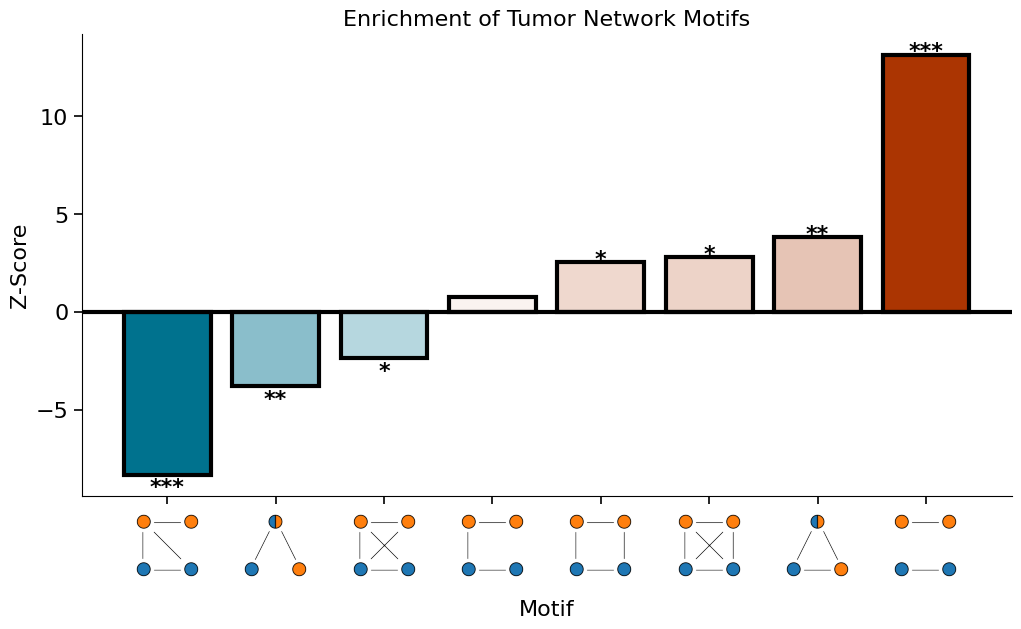

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import os

img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons'
fs = 16

# Use your existing data
motifs = motifs_z.index  # Motif names (e.g., a pandas index)
z_scores = motifs_z.values  # Z-score values (e.g., from a pandas series)

# Create the custom colormap and normalize the z-scores
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', [ncolor, 'white', tcolor])
norm = mcolors.TwoSlopeNorm(vmin=z_scores.min(), vcenter=0, vmax=z_scores.max())
colors = cmap(norm(z_scores))

# Create the bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

bars = ax.bar(
    motifs,       # x values (motifs)
    z_scores,     # y values (z-scores)
    color=colors, # Assign the calculated colors
    edgecolor='k',
    linewidth=3,
)

# Set the image properties
img_width = 0.105  # Fraction of figure width
img_height = img_width  # Maintain aspect ratio

xl, yl, xh, yh = np.array(ax.get_position()).ravel()
w = xh - xl
h = yh - yl

# Calculate dynamic labelpad based on image height
figure_height_in_inches = fig.get_size_inches()[1]
figure_to_axes_ratio = h / figure_height_in_inches
dynamic_labelpad = img_height / figure_to_axes_ratio * 72  # Convert to points (1 inch = 72 points)

# Loop through each motif and replace its x-axis label with an image
for i, label in enumerate(motifs):
    img_path = os.path.join(img_dir, f"{label}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)

        # Get the x-coordinate of the current feature label (in data coordinates)
        label_display_coords = ax.get_xticklabels()[i].get_position()  # Get the label position directly
        label_x = label_display_coords[0]  # Extract the x-coordinate of the label

        # Transform the label's x-coordinate from data coordinates to figure coordinates
        label_display_coords = ax.transData.transform((label_x, 0))  # Data to figure
        fig_coords = fig.transFigure.inverted().transform(label_display_coords)  # Figure coordinates

        # Center the image over the x-axis label
        xpos = fig_coords[0] - img_width / 2  # Adjust x position to center image
        ypos = yl - img_height - 0.03  # Adjust y position below the x-axis labels

        # Add new axes for the image
        ax_img = fig.add_axes([xpos, ypos, img_width, img_height])
        ax_img.axison = False
        ax_img.imshow(img)

# Add a horizontal line at y=0
xlim = ax.get_xlim()
ax.hlines(0, xlim[0], xlim[1], color='k', linestyle='-', linewidth=3)
ax.set_xlim(xlim[0], xlim[1])

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Customize the plot
ax.set_title("Enrichment of Tumor Network Motifs", fontsize=16)
ax.set_xlabel("Motif", fontsize=fs)
ax.set_ylabel("Z-Score", fontsize=fs)
ax.set_xticklabels([])
ax.set_xlabel('Motif', labelpad=65)

# Define significance thresholds
sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

# Loop through bars to annotate significance
for bar, z_score, p_val in zip(bars, z_scores, p_values):
    height = bar.get_height()
    sig_symbol = next((symbol for threshold, symbol in sig_levels.items() if p_val <= threshold), None)
    
    if sig_symbol:
        text_y = height + 0.15 if z_score > 0 else height - 0.15  # Adjust position based on sign
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
            text_y,  # Y position
            sig_symbol,
            ha='center',
            va='center' if z_score > 0 else 'top',  # Adjust vertical alignment
            fontsize=fs,
            fontweight='bold'
        )

# Add a legend for significance symbols with monospaced font
legend_labels = [
    "*   (p ≤ 0.05)",
    "**  (p ≤ 0.01)",
    "*** (p ≤ 0.001)",
]
legend_patches = [
    plt.Line2D([0], [0], color='black', lw=0, marker='', markersize=10, label=label) for label in legend_labels
]
#ax.legend(handles=legend_patches, loc='upper left', fontsize=fs-3, title='Permutation Test', frameon=False)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/tumor_motifs_enrichment_new_rewiring.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/tumor_motifs_enrichment_new_rewiring.png', bbox_inches='tight')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)

ax.tick_params(
    axis='both',
    which='both',
    labelsize=fs,
    direction='out',
    length=6,
    width=1.2,
    colors='black'
)

plt.show()

In [71]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_permutations.csv')
df.sum(1).mean()

/var/tmp/pbs.430686.pbs01/ipykernel_93345/714725727.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df.sum(1).mean()


np.float64(10594.0272)

In [72]:
df = fake_counts
df.sum(1).mean()

/var/tmp/pbs.430686.pbs01/ipykernel_93345/1890780169.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df.sum(1).mean()


np.float64(1460.6306)

In [73]:
motifs_z

motif
4_triangle_extra    -8.465426
3_path              -3.679867
4_one_missing       -2.316426
4_path               0.722599
4_cycle              2.551739
4_clique             2.785035
3_clique             3.679867
4_no_crosstalk      13.655943
Name: z, dtype: float64